<a href="https://colab.research.google.com/github/solomeya12345-code/python_for_data_analitic/blob/main/Homework_4_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому ДЗ ми потренуємось будувати візуалізації з використанням бібліотеки `maplotlib` для візуалізації даних в `pandas.DataFrame`.

# Опис бізнес задачі та набору даних

Набір даних "Yulu" містить інформацію про попит на спільні електровелосипеди в Індії, що надаються провідним індійським постачальником мікромобільності Yulu. Ця компанія пропонує унікальні транспортні засоби для щоденних поїздок з метою усунення транспортних заторів в Індії та забезпечення безпечного, зручного та доступного рішення для пересування. Зони Yulu розташовані в оптимальних місцях, включаючи станції метро, автобусні зупинки, офісні простори, житлові райони та корпоративні офіси, щоб полегшити поїздки на перші та останні кілометри.

Останнім часом Yulu зіткнулася зі значними зниженнями доходів, тому компанія звернулася до консалтингової фірми з метою зрозуміти, від яких факторів залежить попит на ці спільні електровелосипеди, особливо на індійському ринку.

### Профіль колонок набору даних:

- **datetime**: дата та час зібрані погодинно
- **season**: сезон (1: весна, 2: літо, 3: осінь, 4: зима)
- **holiday**: чи є день святковим (витягнуто з http://dchr.dc.gov/page/holiday-schedule)
- **workingday**: якщо день не є вихідним або святковим, то позначається як 1, в іншому випадку – 0.
- **weather**:
  1. Ясно, Мало хмарно, частково хмарно
  2. Туман + Хмарно, Туман + Розірвані хмари, Туман + Мало хмарно, Туман
  3. Легкий сніг, Легкий дощ + Гроза + Розсіяні хмари, Легкий дощ + Розсіяні хмари
  4. Сильний дощ + Крижані кулі + Гроза + Туман, Сніг + Туман
- **temp**: температура в градусах Цельсія
- **atemp**: як відчувається температура в градусах Цельсія
- **humidity**: вологість
- **windspeed**: швидкість вітру
- **casual**: кількість неформальних користувачів
- **registered**: кількість зареєстрованих користувачів
- **count**: загальна кількість велосипедів, взятих в оренду, включаючи неформальних та зареєстрованих користувачів


0. Імпортуйте бібліотеки `matplotlib.pyplot` та `pandas`


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


1. Завантажте дані з файла `yulu_rental.csv` у pandas.DataFrame `df`.

In [4]:
df = pd.read_csv('drive/MyDrive/Python_for_DA/yulu_rental.csv')

2. Виведіть

- перші 3 записи з набору даних
- типи даних в наборі даних
- розміри набору даних

In [35]:
df.head(3)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32


In [37]:
df.dtypes

,0
datetime,object
season,int64
holiday,int64
workingday,int64
weather,int64
temp,float64
atemp,float64
humidity,int64
windspeed,float64
casual,int64


In [39]:
df.shape

(10886, 12)

Альтернативно:

In [60]:
display(df.head(3), df.dtypes, df.shape)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01


,0
datetime,datetime64[ns]
season,int64
holiday,int64
workingday,int64
weather,int64
temp,float64
atemp,float64
humidity,int64
windspeed,float64
casual,int64


(10886, 13)

Перетворимо колонку `datetime` на тип даних `pd.datetime` - це нам доопоможе в подальшій роботі. Просто запустіть колонку нижче і занатуйте собі цей метод роботи з колонкою, в якій міститься дата і час.
Наша колонка тепер стане таймпстемпом і для неї став доступний функціонал, описаний тут

https://pandas.pydata.org/docs/reference/api/pandas.Timestamp.html

Наприклад, ми можемо легко виокремити дату, день тижня, чи це робочий день, чи ні.

In [5]:
df['datetime'] = pd.to_datetime(df.datetime)

3. З допомогою matplotlib побудуйте найпростіший лінійний графік кількості зареєстрованих користувачів (`registered`) на кожну годину.

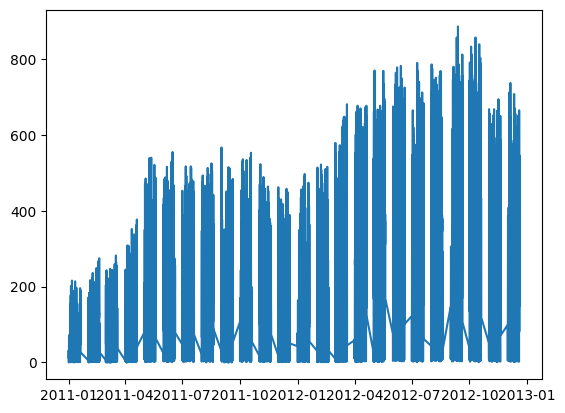

In [6]:
plt.plot(df['datetime'], df['registered']);

Має вийти щось таке:
![](https://drive.google.com/uc?export=view&id=1WX6s9qmiwq_1TSHQtRX0bPL8sT6Gw2BH)

4. Графік виглядає так собі, правда? Давайте загрегуємо дані по дням. Для цього запустіть наступний код аби створити колонку "дата" (без часу) і після цього напишіть самостійно код, аби загрегувати дані і отримати кількість зарестрованих клієнтів на день. Ваша фінальна структура (запишіть її в змінну `df_registered_by_date`) даних має містити дві колонки: дату і кількість зареєстрованих користувачів на цей день.

In [7]:
df['date'] = df.datetime.dt.date

In [61]:
df_registered_by_date = df.groupby(['date'])['registered'].sum().reset_index()
df_registered_by_date


,date,registered
0,2011-01-01,654
1,2011-01-02,670
2,2011-01-03,1229
3,2011-01-04,1454
4,2011-01-05,1518
...,...,...
451,2012-12-15,4280
452,2012-12-16,3248
453,2012-12-17,4373
454,2012-12-18,5124


Очікуваний результат:

![](https://drive.google.com/uc?export=view&id=1DL7Y-R7_CBWNlQNAnMyAoU8hR2MdF5v7)


5. Тепер побудуйте лінійний графік з matplotlib для даних в `df_registered_by_date`.

  Додайте наступну частину до графіку аби зробити підписи за віссю ОХ більш читаємими

  `plt.xticks(rotation=45, ha='right')`

  Після побудови графіку проаналізуйте його та напишіть, які тенденції щодо зміни кількості зареєстрованих користувачів в часі ви бачите і чому так може бути?

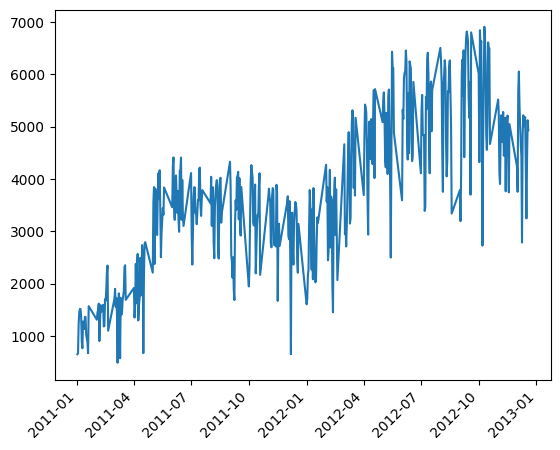

In [9]:
plt.plot(df_registered_by_date);
plt.xticks(rotation=45, ha='right');

Мабуть правильніші варіанти:

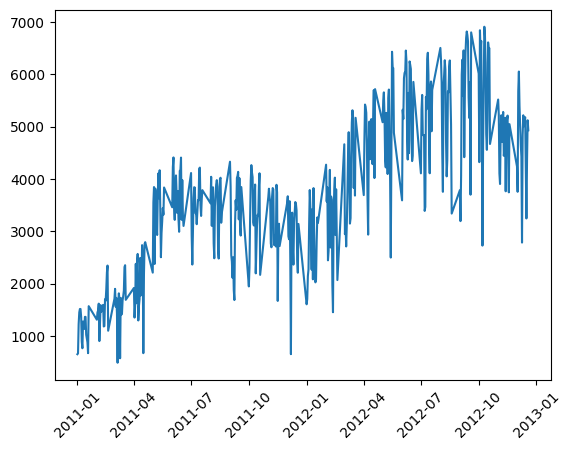

In [62]:
plt.plot(df_registered_by_date.date, df_registered_by_date.registered)
plt.xticks(rotation=45);

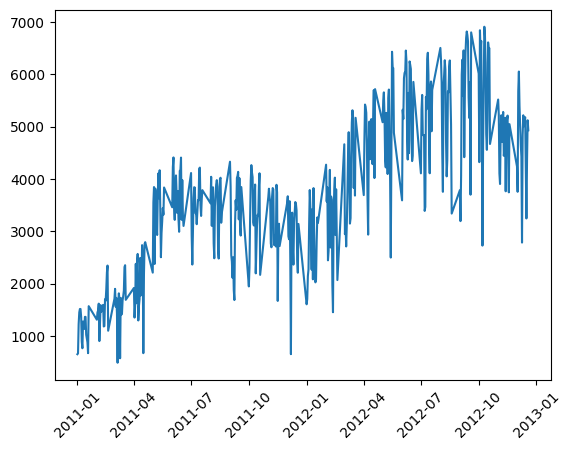

In [63]:
# інший спосіб, коли в нас є датафрейм
plt.plot('date', 'registered', data=df_registered_by_date)
plt.xticks(rotation=45);

На графіку помітна тенденція, що з квітня по липень кількість зареєстрованих користувачів збільшується, а з жовтня по січень кількість зменшується.
Це може бути пов'язано з погіршенням погодних умов, відповідно, це знижений попит на такий незахищений вид транспорту.

Загалом з часот помітний тренд зростання, що може свідчити про збільшення популярності сервісу.

Розв'язок:

**Відповідь на питання**:
Згідно з наведеним графіком, можна визначити кілька тенденцій щодо зміни кількості зареєстрованих користувачів сервісу спільного використання велосипедів:

1. **Сезонні коливання**: Є чітка сезонна тенденція з піками, які, ймовірно, припадають на тепліші місяці (весна та літо) та спадами у холодніші місяці (осінь та зима). Це може бути пов'язано з комфортністю користування велосипедами в теплу пору року порівняно з несприятливими погодними умовами в холодні місяці.

2. **Тренд зростання**: З часом загальна кількість зареєстрованих користувачів зростає, що може свідчити про збільшення популярності сервісу, підвищення обізнаності серед населення або розширення мережі зон Yulu.

3. **Тижневі/денні коливання**: Здається, що є короткочасні спади, які можуть відбуватися щотижня. Це може бути пов'язано з вихідними, коли люди менше користуються велосипедами для добирання до роботи.

Такі спостереження можуть бути корисними для оптимізації кількості доступних велосипедів, планування маркетингових кампаній, а також для розробки стратегій розміщення нових зон bike-sharing.

6. Побудуйте графік розсіювання (scatterplot) між температурою і тим, як вона відчувається (atemp). Поставте прозорість точок 0.2. Додайте підписи до осей Х ат У. Опишіть свої спостереження з цього графіку. Які висновки можна зробити? Що дивного бачите?

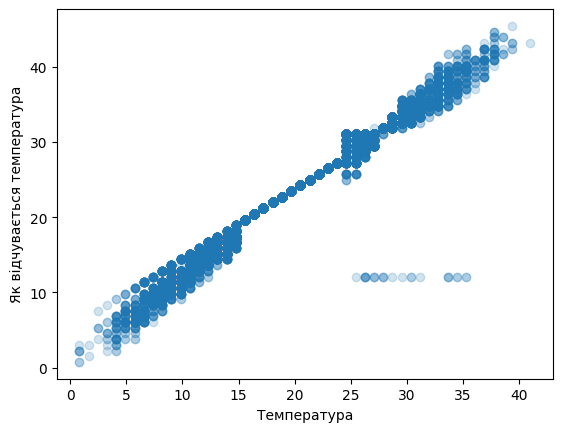

In [11]:
plt.scatter(df['temp'], df['atemp'], alpha=0.2)
plt.xlabel('Температура')
plt.ylabel('Як відчувається температура');

Альтернативно:

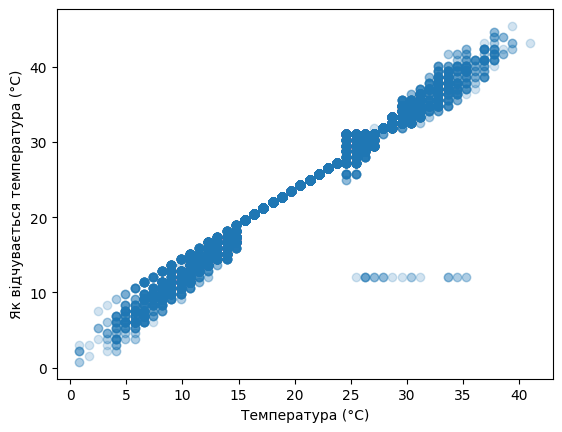

In [64]:
plt.scatter('temp', 'atemp', data=df, alpha=0.2)
plt.xlabel('Температура (°C)')
plt.ylabel('Як відчувається температура (°C)');

  Очікуваний графік:
![](https://drive.google.com/uc?export=view&id=13Mi6AGPUh5aQ5YEZjrlkQPuFcNzeeppB)


Температура відчувається також ж, або меншою від 0 до 15 градусів. Відчувається суто так, як є – від 15 до 25 градусів. Здебільшого відчувається тепліше, або такою як є – від 25 до 30 градусів. Переважно відчувається більшою – від 30 до 40 градусів.

Також у нас є підозрілі дані, що свідчать про те, що температура була від 25 до 35 градусів, але відчувалась на 12.12, можливо, це якась помилка або неправильні дані.

Розв'язок:

**Відповідь**
З наданого графіку розсіювання між температурою та відчуваною температурою можна зробити наступні спостереження:

1. **Сильна пряма лінійна залежність**: Існує сильна позитивна кореляція між температурою та відчуваною температурою. Точки утворюють майже пряму лінію, що вказує на те, що відчувана температура збільшується разом із реальною температурою. Що логічно.

2. **Нелінійність відношень**: Деякі точки формують криві, зокрема в діапазонах низьких і високих температур. Це може означати, що відчуття температури змінюється нелінійно в залежності від реальної температури, з можливими більшими відхиленнями при дуже низьких або високих температурах.

3. **Аномалії**: Є група точок (близько 11 градусів за відчуваною температурою), які лежать поза основною тенденцією, з відчуваною температурою значно вищою за реальну. Ці точки можуть вказувати на помилки в даних або на особливі погодні умови, де вплив вологості чи вітру змінює відчуття температури (зважаючи, що точки утворюють лінію - це менш імовірно).

In [59]:
df_filter_1 = df[(df.atemp > 10) & (df.atemp <= 13) & (df.temp >= 25) & (df.temp <= 37)]
df_filter_1

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date
8991,2012-08-17 00:00:00,3,0,1,1,27.88,12.12,57,11.0014,21,67,88,2012-08-17
8992,2012-08-17 01:00:00,3,0,1,1,27.06,12.12,65,7.0015,16,38,54,2012-08-17
8993,2012-08-17 02:00:00,3,0,1,1,27.06,12.12,61,8.9981,4,15,19,2012-08-17
8994,2012-08-17 03:00:00,3,0,1,1,26.24,12.12,65,7.0015,0,6,6,2012-08-17
8995,2012-08-17 04:00:00,3,0,1,1,26.24,12.12,73,11.0014,0,9,9,2012-08-17
8996,2012-08-17 05:00:00,3,0,1,1,26.24,12.12,73,7.0015,2,34,36,2012-08-17
8997,2012-08-17 06:00:00,3,0,1,1,25.42,12.12,78,8.9981,6,151,157,2012-08-17
8998,2012-08-17 07:00:00,3,0,1,1,26.24,12.12,73,7.0015,11,368,379,2012-08-17
8999,2012-08-17 08:00:00,3,0,1,1,27.88,12.12,65,8.9981,43,625,668,2012-08-17
9000,2012-08-17 09:00:00,3,0,1,1,28.70,12.12,58,7.0015,58,320,378,2012-08-17
